# Aggregate fio read bytes and throughput across ranks

Sums the per-rank `read.io_bytes` and bandwidth from the fio JSON output files
(one file per MPI rank). Rank files may have a non-JSON header line (an MPI/PBS
error message), so parsing starts at the first `{`.

Two aggregate throughput numbers are reported:
- **Sum of per-rank bw**: each rank's own `bw_bytes` summed (optimistic; ignores rank skew).
- **Total bytes / max runtime**: wall-clock view, bounded by the slowest rank.


In [2]:
import json
import glob
from pathlib import Path

# Folder containing one fio JSON file per rank
RESULT_DIR = Path("read_1tib_n2_ppn32_bs2m_iod16_8650075")

files = sorted(RESULT_DIR.glob("*.json"))
print(f"{len(files)} rank files")

64 rank files


In [3]:
def load_fio_json(path):
    """Parse a fio JSON file, skipping any non-JSON header lines."""
    txt = Path(path).read_text()
    return json.loads(txt[txt.index("{"):])

per_rank = []
for fp in files:
    d = load_fio_json(fp)
    per_rank.append({
        "file": fp.name,
        "io_bytes": sum(j["read"]["io_bytes"] for j in d["jobs"]),
        "bw_bytes": sum(j["read"]["bw_bytes"] for j in d["jobs"]),
        "runtime_ms": max(j["read"]["runtime"] for j in d["jobs"]),
    })

In [4]:
GiB = 1024**3

total_bytes = sum(r["io_bytes"] for r in per_rank)
total_bw_bytes = sum(r["bw_bytes"] for r in per_rank)
max_rt_s = max(r["runtime_ms"] for r in per_rank) / 1000
min_rt_s = min(r["runtime_ms"] for r in per_rank) / 1000

print(f"Aggregated read bytes    : {total_bytes} B = {total_bytes/GiB:.2f} GiB = {total_bytes/1024**4:.4f} TiB")
print(f"Runtime (min-max)        : {min_rt_s:.1f} - {max_rt_s:.1f} s")
print(f"Sum of per-rank bw       : {total_bw_bytes/GiB:.2f} GiB/s = {total_bw_bytes/1e9:.2f} GB/s")
print(f"Total bytes / max runtime: {total_bytes/max_rt_s/GiB:.2f} GiB/s = {total_bytes/max_rt_s/1e9:.2f} GB/s")

Aggregated read bytes    : 1099511627776 B = 1024.00 GiB = 1.0000 TiB
Runtime (min-max)        : 10.3 - 13.9 s
Sum of per-rank bw       : 84.41 GiB/s = 90.63 GB/s
Total bytes / max runtime: 73.82 GiB/s = 79.27 GB/s


## Comparison: single-process run (`fio-read1TiB-seqread-fs16g.json`)

A single fio invocation with `numjobs=64`, `size=16gb` per job, `group_reporting=1`
(one JSON file for the whole run), vs. the 32-rank MPI run above.

In [5]:
SINGLE_RUN = Path("fio-read1TiB-seqread-fs16g.json")

d = load_fio_json(SINGLE_RUN)
single = {
    "io_bytes": sum(j["read"]["io_bytes"] for j in d["jobs"]),
    "bw_bytes": sum(j["read"]["bw_bytes"] for j in d["jobs"]),
    "runtime_s": max(j["read"]["runtime"] for j in d["jobs"]) / 1000,
}
print(f"read bytes : {single['io_bytes']} B = {single['io_bytes']/GiB:.2f} GiB = {single['io_bytes']/1024**4:.4f} TiB")
print(f"runtime    : {single['runtime_s']:.1f} s")
print(f"bandwidth  : {single['bw_bytes']/GiB:.2f} GiB/s = {single['bw_bytes']/1e9:.2f} GB/s")

read bytes : 1099511627776 B = 1024.00 GiB = 1.0000 TiB
runtime    : 38.1 s
bandwidth  : 26.85 GiB/s = 28.83 GB/s


In [6]:
rows = [
    ("MPI run", total_bytes, max_rt_s, total_bw_bytes, total_bytes / max_rt_s),
    ("single-process run", single["io_bytes"], single["runtime_s"], single["bw_bytes"], single["io_bytes"] / single["runtime_s"]),
]

hdr = f"{'run':<20} {'read GiB':>10} {'runtime s':>10} {'sum bw GiB/s':>13} {'wall bw GiB/s':>14}"
print(hdr)
print("-" * len(hdr))
for name, b, rt, bw, wall in rows:
    print(f"{name:<20} {b/GiB:>10.2f} {rt:>10.1f} {bw/GiB:>13.2f} {wall/GiB:>14.2f}")

ratio = (total_bytes / max_rt_s) / (single["io_bytes"] / single["runtime_s"])
print(f"\nMPI run wall-clock bandwidth is {ratio:.2f}x the single-process run")

run                    read GiB  runtime s  sum bw GiB/s  wall bw GiB/s
-----------------------------------------------------------------------
MPI run                 1024.00       13.9         84.41          73.82
single-process run      1024.00       38.1         26.85          26.85

MPI run wall-clock bandwidth is 2.75x the single-process run


## Iteration-by-iteration: repeated-read job (`read_1tib_n2_ppn32_bs2m_iod16_8651348`)

This job repeats the 64-rank read pass NITERS times (see `qsub_fio_read_1tib.qsub`);
each pass writes 64 rank files labelled `..._iterNN_<epoch>_rankNNN.json`.
Files are grouped by their `iterNN` tag and each iteration is aggregated the
same way as above (sum of per-rank bw, and total bytes / max runtime).

In [7]:
import re
from collections import defaultdict

# All raw rank JSONs live in the read_1tib_n2_ppn32_bs2m_iod16_* job folders.
# Group by (job folder, iterNN tag); files without an iter tag (the older
# single-pass job) fall into one "-" group for that folder.
runs = defaultdict(list)  # (job, iter_tag) -> [rank json paths]
for fp in sorted(Path(".").glob("read_1tib_n2_ppn32_bs2m_iod16_*/*.json")):
    m = re.search(r"iter(\d+)", fp.name)
    runs[(fp.parent.name, m.group(1) if m else "-")].append(fp)

def aggregate(paths):
    """Aggregate one pass (a set of per-rank fio JSONs) -> summary dict."""
    io_b = bw_b = 0
    rts = []
    for fp in paths:
        d = load_fio_json(fp)
        io_b += sum(j["read"]["io_bytes"] for j in d["jobs"])
        bw_b += sum(j["read"]["bw_bytes"] for j in d["jobs"])
        rts.append(max(j["read"]["runtime"] for j in d["jobs"]) / 1000)
    return {"nranks": len(paths), "io_bytes": io_b, "bw_bytes": bw_b,
            "rt_min_s": min(rts), "rt_max_s": max(rts),
            "wall_bw": io_b / max(rts)}

per_iter = {key: aggregate(paths) for key, paths in sorted(runs.items())}

hdr = (f"{'job':<42} {'iter':>4} {'ranks':>5} {'read GiB':>9} "
       f"{'rt min-max s':>13} {'sum bw GiB/s':>13} {'wall bw GiB/s':>14}")
print(hdr)
print("-" * len(hdr))
for (job, it), a in per_iter.items():
    print(f"{job:<42} {it:>4} {a['nranks']:>5} {a['io_bytes']/GiB:>9.2f} "
          f"{a['rt_min_s']:>6.1f}-{a['rt_max_s']:<6.1f} "
          f"{a['bw_bytes']/GiB:>13.2f} {a['wall_bw']/GiB:>14.2f}")

job                                        iter ranks  read GiB  rt min-max s  sum bw GiB/s  wall bw GiB/s
----------------------------------------------------------------------------------------------------------
read_1tib_n2_ppn32_bs2m_iod16_8650075         -    64   1024.00   10.3-13.9           84.41          73.82
read_1tib_n2_ppn32_bs2m_iod16_8651348        01    64   1024.00    4.4-14.3           91.90          71.79
read_1tib_n2_ppn32_bs2m_iod16_8651348        02    64   1024.00    3.6-11.5          126.24          88.69
read_1tib_n2_ppn32_bs2m_iod16_8651348        03    64   1024.00    4.2-12.6          113.79          81.51
read_1tib_n2_ppn32_bs2m_iod16_8651348        04    64   1024.00    4.5-12.2          127.72          83.71
read_1tib_n2_ppn32_bs2m_iod16_8651348        05    64   1024.00    2.9-11.4          133.69          89.92
read_1tib_n2_ppn32_bs2m_iod16_8651348        06    64   1024.00    2.8-11.0          146.11          93.18
read_1tib_n2_ppn32_bs2m_iod16_8651348

In [8]:
import statistics as st

# Stability across the repeated passes (iter-tagged runs only)
w = [a["wall_bw"] / GiB for (job, it), a in per_iter.items() if it != "-"]
print(f"wall-clock bw over {len(w)} iterations:")
print(f"  mean {st.mean(w):.2f}  stdev {st.stdev(w):.2f}  "
      f"min {min(w):.2f}  max {max(w):.2f} GiB/s")

wall-clock bw over 9 iterations:
  mean 84.55  stdev 6.07  min 71.79  max 93.18 GiB/s


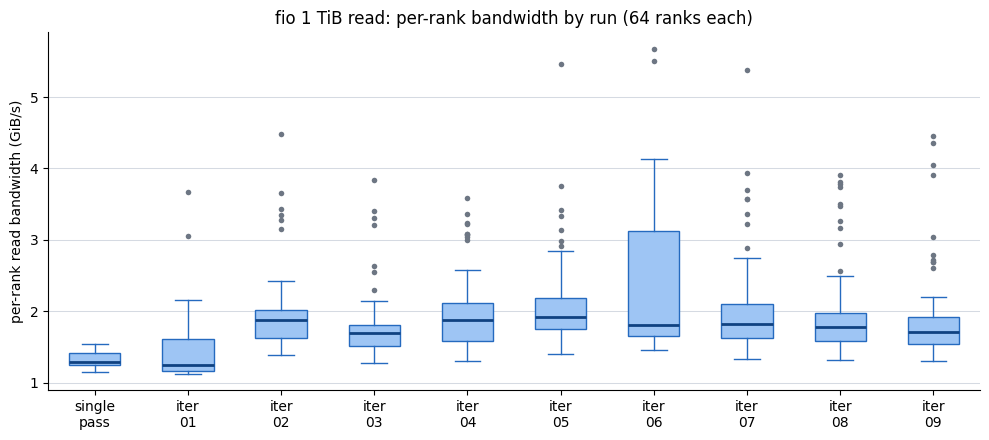

In [9]:
import matplotlib.pyplot as plt

# Per-rank bandwidth for every run: the single-pass job (8650075) plus the
# 9 iterations of the repeated job (8651348) -> 10 groups of 64 ranks.
labels, groups = [], []
for (job, it), paths in sorted(runs.items()):
    labels.append("single\npass" if it == "-" else f"iter\n{it}")
    groups.append([sum(j["read"]["bw_bytes"] for j in load_fio_json(fp)["jobs"]) / GiB
                   for fp in paths])

fig, ax = plt.subplots(figsize=(10, 4.5))
bp = ax.boxplot(groups, patch_artist=True, widths=0.55,
                medianprops=dict(color="#104281", linewidth=2),
                boxprops=dict(facecolor="#9ec5f4", edgecolor="#256abf", linewidth=1),
                whiskerprops=dict(color="#256abf", linewidth=1),
                capprops=dict(color="#256abf", linewidth=1),
                flierprops=dict(marker="o", markersize=4,
                                markerfacecolor="#6d7683", markeredgecolor="none"))
ax.set_xticks(range(1, len(labels) + 1))
ax.set_xticklabels(labels)

ax.set_ylabel("per-rank read bandwidth (GiB/s)")
ax.set_title("fio 1 TiB read: per-rank bandwidth by run (64 ranks each)")
ax.yaxis.grid(True, color="#d5dae2", linewidth=0.75)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
plt.tight_layout()
plt.show()

## Random read: n2_ppn32 jobs (`randread_fio-1tib-fs16g_n2_ppn32_bs2m_iod16_*`)

Same analysis as the sequential read above, for the `PATTERN=randread` jobs at
the n2 x ppn32 layout: the repeated job 8651525 (10 iterations x 64 ranks;
folder renamed from `randread_1tib_...` to the current container-based naming)
plus the single cold pass 8660443. Per-iteration aggregates, stability stats,
and a per-rank bandwidth box plot grouped by pass.

In [18]:
# Group the randread rank files by (job folder, iterNN tag), aggregate each
# iteration with the same aggregate() as the sequential-read section.
# Covers both n2_ppn32 randread jobs: 8651525 (10 iterations) and the single
# cold pass 8660443.
rand_runs = defaultdict(list)
for fp in sorted(Path(".").glob("randread_fio-1tib-fs16g_n2_ppn32_bs2m_iod16_*/*.json")):
    m = re.search(r"iter(\d+)", fp.name)
    rand_runs[(fp.parent.name, m.group(1) if m else "-")].append(fp)

rand_per_iter = {key: aggregate(paths) for key, paths in sorted(rand_runs.items())}

hdr = (f"{'job':<50} {'iter':>4} {'ranks':>5} {'read GiB':>9} "
       f"{'rt min-max s':>13} {'sum bw GiB/s':>13} {'wall bw GiB/s':>14}")
print(hdr)
print("-" * len(hdr))
for (job, it), a in rand_per_iter.items():
    print(f"{job:<50} {it:>4} {a['nranks']:>5} {a['io_bytes']/GiB:>9.2f} "
          f"{a['rt_min_s']:>6.1f}-{a['rt_max_s']:<6.1f} "
          f"{a['bw_bytes']/GiB:>13.2f} {a['wall_bw']/GiB:>14.2f}")

w = [a["wall_bw"] / GiB for a in rand_per_iter.values()]
print(f"\nwall-clock bw over {len(w)} passes:")
print(f"  mean {st.mean(w):.2f}  stdev {st.stdev(w):.2f}  "
      f"min {min(w):.2f}  max {max(w):.2f} GiB/s")

job                                                iter ranks  read GiB  rt min-max s  sum bw GiB/s  wall bw GiB/s
------------------------------------------------------------------------------------------------------------------
randread_fio-1tib-fs16g_n2_ppn32_bs2m_iod16_8651525   01    64   1024.00    8.4-14.0           82.63          73.13
randread_fio-1tib-fs16g_n2_ppn32_bs2m_iod16_8651525   02    64   1024.00    2.9-10.8          130.07          94.73
randread_fio-1tib-fs16g_n2_ppn32_bs2m_iod16_8651525   03    64   1024.00    3.1-11.3          144.13          90.75
randread_fio-1tib-fs16g_n2_ppn32_bs2m_iod16_8651525   04    64   1024.00    2.8-11.2          157.22          91.39
randread_fio-1tib-fs16g_n2_ppn32_bs2m_iod16_8651525   05    64   1024.00    2.9-11.3          143.55          91.01
randread_fio-1tib-fs16g_n2_ppn32_bs2m_iod16_8651525   06    64   1024.00    2.9-11.4          142.82          89.66
randread_fio-1tib-fs16g_n2_ppn32_bs2m_iod16_8651525   07    64   1024.00  

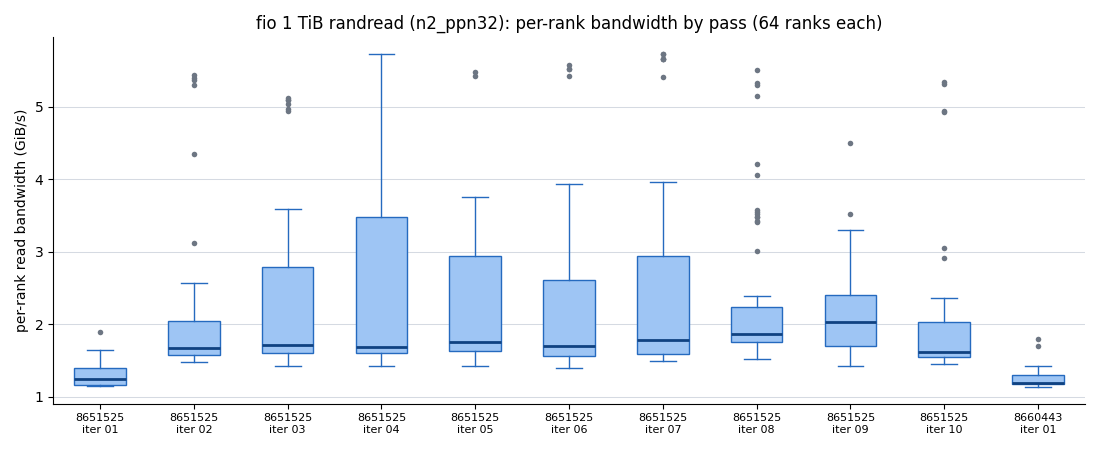

In [19]:
# Box plot: per-rank randread bandwidth, one box per pass (64 ranks each).
# Labels carry the job id suffix since two jobs both have an iter01.
rand_labels, rand_groups = [], []
for (job, it), paths in sorted(rand_runs.items()):
    rand_labels.append(f"{job.rsplit('_', 1)[-1]}\niter {it}")
    rand_groups.append([sum(j["read"]["bw_bytes"] for j in load_fio_json(fp)["jobs"]) / GiB
                        for fp in paths])

fig, ax = plt.subplots(figsize=(11, 4.5))
bp = ax.boxplot(rand_groups, patch_artist=True, widths=0.55,
                medianprops=dict(color="#104281", linewidth=2),
                boxprops=dict(facecolor="#9ec5f4", edgecolor="#256abf", linewidth=1),
                whiskerprops=dict(color="#256abf", linewidth=1),
                capprops=dict(color="#256abf", linewidth=1),
                flierprops=dict(marker="o", markersize=4,
                                markerfacecolor="#6d7683", markeredgecolor="none"))
ax.set_xticks(range(1, len(rand_labels) + 1))
ax.set_xticklabels(rand_labels, fontsize=8)

ax.set_ylabel("per-rank read bandwidth (GiB/s)")
ax.set_title("fio 1 TiB randread (n2_ppn32): per-rank bandwidth by pass (64 ranks each)")
ax.yaxis.grid(True, color="#d5dae2", linewidth=0.75)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
plt.tight_layout()
plt.show()

## First iteration of each run

Pulls out the `iter01` (or the single un-tagged pass) summary for every job
folder seen above, since the first pass may be affected by cold caches.

In [12]:
def first_iter_per_job(per_iter_dict):
    """(job, iter_tag) -> summary  =>  job -> (first_iter_tag, summary).

    Zero-padded iter tags ("01".."09") sort correctly as strings, and "-"
    (single-pass job) sorts before any digit, so plain min() finds the
    first pass for each job.
    """
    by_job = defaultdict(dict)
    for (job, it), a in per_iter_dict.items():
        by_job[job][it] = a
    return {job: (min(iters), iters[min(iters)]) for job, iters in by_job.items()}

first_iters = {**first_iter_per_job(per_iter), **first_iter_per_job(rand_per_iter)}

hdr = (f"{'job':<46} {'iter':>4} {'ranks':>5} {'read GiB':>9} "
       f"{'rt min-max s':>13} {'sum bw GiB/s':>13} {'wall bw GiB/s':>14}")
print(hdr)
print("-" * len(hdr))
for job, (it, a) in sorted(first_iters.items()):
    print(f"{job:<46} {it:>4} {a['nranks']:>5} {a['io_bytes']/GiB:>9.2f} "
          f"{a['rt_min_s']:>6.1f}-{a['rt_max_s']:<6.1f} "
          f"{a['bw_bytes']/GiB:>13.2f} {a['wall_bw']/GiB:>14.2f}")

job                                            iter ranks  read GiB  rt min-max s  sum bw GiB/s  wall bw GiB/s
--------------------------------------------------------------------------------------------------------------
randread_1tib_n2_ppn32_bs2m_iod16_8651525        01    64   1024.00    8.4-14.0           82.63          73.13
read_1tib_n2_ppn32_bs2m_iod16_8650075             -    64   1024.00   10.3-13.9           84.41          73.82
read_1tib_n2_ppn32_bs2m_iod16_8651348            01    64   1024.00    4.4-14.3           91.90          71.79


## New job families: `n4_ppn16` and `n8_ppn8` fs16g runs (cold passes)

These jobs vary the node/ppn layout while keeping 64 ranks total
(`cont=fio-1tib-fs16g`, 16 GiB/rank): 4 nodes x 16 ranks/node and
8 nodes x 8 ranks/node. Each job folder is a single cold `iter01` pass:

- `read_fio-1tib-fs16g_n4_ppn16_bs2m_iod16_8659887` / `..._8660049` (sequential read)
- `randread_fio-1tib-fs16g_n4_ppn16_bs2m_iod16_8660091` / `..._8660132` (random read)
- `read_fio-1tib-fs16g_n8_ppn8_bs2m_iod16_8660218` / `..._8660244` (sequential read)
- `randread_fio-1tib-fs16g_n8_ppn8_bs2m_iod16_8660298` / `..._8660372` (random read)

Every rank file in each folder is verified individually (JSON parses, nonzero
read bytes/runtime) before aggregating.

In [20]:
# n4_ppn16 + n8_ppn8 "fs16g" job families (still 64 ranks total).
# Each job folder holds a single cold iter01 pass.
n4_runs = defaultdict(list)
for fp in sorted(Path(".").glob("*fio-1tib-fs16g_n[48]_ppn*/*.json")):
    m = re.search(r"iter(\d+)", fp.name)
    n4_runs[(fp.parent.name, m.group(1) if m else "-")].append(fp)

print(f"{len(n4_runs)} job/iter groups found:")
for (job, it), paths in sorted(n4_runs.items()):
    print(f"  {job:<54} iter {it}  {len(paths)} rank files")

8 job/iter groups found:
  randread_fio-1tib-fs16g_n4_ppn16_bs2m_iod16_8660091    iter 01  64 rank files
  randread_fio-1tib-fs16g_n4_ppn16_bs2m_iod16_8660132    iter 01  64 rank files
  randread_fio-1tib-fs16g_n8_ppn8_bs2m_iod16_8660298     iter 01  64 rank files
  randread_fio-1tib-fs16g_n8_ppn8_bs2m_iod16_8660372     iter 01  64 rank files
  read_fio-1tib-fs16g_n4_ppn16_bs2m_iod16_8659887        iter 01  64 rank files
  read_fio-1tib-fs16g_n4_ppn16_bs2m_iod16_8660049        iter 01  64 rank files
  read_fio-1tib-fs16g_n8_ppn8_bs2m_iod16_8660218         iter 01  64 rank files
  read_fio-1tib-fs16g_n8_ppn8_bs2m_iod16_8660244         iter 01  64 rank files


In [21]:
# Verify each rank file individually: JSON parses, and read bytes/runtime are nonzero.
bad = []
for (job, it), paths in sorted(n4_runs.items()):
    for fp in paths:
        try:
            d = load_fio_json(fp)
            io_b = sum(j["read"]["io_bytes"] for j in d["jobs"])
            rt = max(j["read"]["runtime"] for j in d["jobs"])
            if io_b == 0 or rt == 0:
                bad.append((fp, "zero io_bytes or runtime"))
        except Exception as e:
            bad.append((fp, str(e)))

if bad:
    print(f"{len(bad)} problem file(s):")
    for fp, reason in bad:
        print(f"  {fp}: {reason}")
else:
    total_files = sum(len(paths) for paths in n4_runs.values())
    print(f"All {total_files} rank files parsed cleanly with nonzero read bytes/runtime.")

All 512 rank files parsed cleanly with nonzero read bytes/runtime.


In [22]:
n4_per_iter = {key: aggregate(paths) for key, paths in sorted(n4_runs.items())}

wide_hdr = (f"{'job':<54} {'iter':>4} {'ranks':>5} {'read GiB':>9} "
            f"{'rt min-max s':>13} {'sum bw GiB/s':>13} {'wall bw GiB/s':>14}")
print(wide_hdr)
print("-" * len(wide_hdr))
for (job, it), a in n4_per_iter.items():
    print(f"{job:<54} {it:>4} {a['nranks']:>5} {a['io_bytes']/GiB:>9.2f} "
          f"{a['rt_min_s']:>6.1f}-{a['rt_max_s']:<6.1f} "
          f"{a['bw_bytes']/GiB:>13.2f} {a['wall_bw']/GiB:>14.2f}")

job                                                    iter ranks  read GiB  rt min-max s  sum bw GiB/s  wall bw GiB/s
----------------------------------------------------------------------------------------------------------------------
randread_fio-1tib-fs16g_n4_ppn16_bs2m_iod16_8660091      01    64   1024.00    2.5-7.8           194.83         131.60
randread_fio-1tib-fs16g_n4_ppn16_bs2m_iod16_8660132      01    64   1024.00    2.5-7.3           187.98         140.33
randread_fio-1tib-fs16g_n8_ppn8_bs2m_iod16_8660298       01    64   1024.00    3.2-4.2           271.10         243.17
randread_fio-1tib-fs16g_n8_ppn8_bs2m_iod16_8660372       01    64   1024.00    3.0-3.5           314.71         293.75
read_fio-1tib-fs16g_n4_ppn16_bs2m_iod16_8659887          01    64   1024.00    2.6-7.7           208.66         132.69
read_fio-1tib-fs16g_n4_ppn16_bs2m_iod16_8660049          01    64   1024.00    2.7-7.9           192.20         130.40
read_fio-1tib-fs16g_n8_ppn8_bs2m_iod16_8660218  

In [23]:
# Fold the n4_ppn16 jobs into the combined "first iteration of each run" table.
first_iters = {**first_iters, **first_iter_per_job(n4_per_iter)}

print(wide_hdr)
print("-" * len(wide_hdr))
for job, (it, a) in sorted(first_iters.items()):
    print(f"{job:<54} {it:>4} {a['nranks']:>5} {a['io_bytes']/GiB:>9.2f} "
          f"{a['rt_min_s']:>6.1f}-{a['rt_max_s']:<6.1f} "
          f"{a['bw_bytes']/GiB:>13.2f} {a['wall_bw']/GiB:>14.2f}")

job                                                    iter ranks  read GiB  rt min-max s  sum bw GiB/s  wall bw GiB/s
----------------------------------------------------------------------------------------------------------------------
randread_fio-1tib-fs16g_n2_ppn32_bs2m_iod16_8651525      01    64   1024.00    8.4-14.0           82.63          73.13
randread_fio-1tib-fs16g_n2_ppn32_bs2m_iod16_8660443      01    64   1024.00    8.9-14.1           80.00          72.49
randread_fio-1tib-fs16g_n4_ppn16_bs2m_iod16_8660091      01    64   1024.00    2.5-7.8           194.83         131.60
randread_fio-1tib-fs16g_n4_ppn16_bs2m_iod16_8660132      01    64   1024.00    2.5-7.3           187.98         140.33
randread_fio-1tib-fs16g_n8_ppn8_bs2m_iod16_8660298       01    64   1024.00    3.2-4.2           271.10         243.17
randread_fio-1tib-fs16g_n8_ppn8_bs2m_iod16_8660372       01    64   1024.00    3.0-3.5           314.71         293.75
read_1tib_n2_ppn32_bs2m_iod16_8650075           

## Per-rank size check: every rank reads exactly 16 GiB

The aggregates above only confirm the *total* across 64 ranks is 1 TiB, which
is also true if ranks are uneven. This checks each individual rank file's
`read.io_bytes` across every 1 TiB read/randread job seen in this notebook
(`read_1tib_n2_ppn32_*`, `randread_fio-1tib-fs16g_n2_ppn32_*`, and the
`fio-1tib-fs16g_n4_ppn16_*` / `n8_ppn8_*` families) against the expected
`16 * 1024**3` bytes.

In [24]:
EXPECTED_RANK_BYTES = 16 * 1024**3  # 16 GiB

all_rank_files = []
for run_dict in (runs, rand_runs, n4_runs):
    for paths in run_dict.values():
        all_rank_files.extend(paths)

sizes_seen = set()
mismatches = []
for fp in all_rank_files:
    d = load_fio_json(fp)
    io_b = sum(j["read"]["io_bytes"] for j in d["jobs"])
    sizes_seen.add(io_b)
    if io_b != EXPECTED_RANK_BYTES:
        mismatches.append((fp, io_b))

njobs = len({fp.parent.name for fp in all_rank_files})
print(f"Checked {len(all_rank_files)} rank files across {njobs} job folders")
print(f"Unique read.io_bytes values seen: {sizes_seen}")
if mismatches:
    print(f"\n{len(mismatches)} rank(s) did NOT read exactly 16 GiB:")
    for fp, b in mismatches[:20]:
        print(f"  {fp}: {b} B = {b/GiB:.4f} GiB")
else:
    print(f"\nAll ranks read exactly {EXPECTED_RANK_BYTES} B = 16.0000 GiB. No mismatches.")

Checked 1856 rank files across 12 job folders
Unique read.io_bytes values seen: {17179869184}

All ranks read exactly 17179869184 B = 16.0000 GiB. No mismatches.
